<p align="center">
  <img width="800" height="400" src="https://uploads.toptal.com/blog/image/121412/toptal-blog-image-1478600437768-72348223698908b523c4b825b9e0befe.png"> 
</p>

Bioinformatics is an interdisciplinary field that develops methods and software tools for analyzing and understanding biological data. 

Among the many types of biological data, genomics data is one of the most widely analyzed. Especially with the rapid advancement of next-generation DNA sequencing (NGS) technologies, the volume of genomics data has been growing exponentially. According to [Stephens, Zachary D et al.](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.1002195), genomics data acquisition is on the exabyte-per-year scale.

This project will answer the following questions about the human genome:

- How much of the genome is incomplete?
- How many genes are there in the genome?
- How long is a typical gene?
- What does gene distribution among chromosomes look like?

The latest GFF3 file for the human genome can be downloaded from [here](ftp://ftp.ensembl.org/pub/release-85/gff3/homo_sapiens). The [README](http://ftp.ensembl.org/pub/release-85/gff3/homo_sapiens/README) file that comes in this directory provides a brief description of this data format, and a more thorough specification is found [here](https://github.com/The-Sequence-Ontology/Specifications/blob/master/gff3.md#generic-feature-format-version-3-gff3).

[Genome Reference Consortium](https://www.ncbi.nlm.nih.gov/grc (GRC) is an international consortium, which oversees updates and improvements to several reference genome assemblies, including those for human, mouse, zebrafish, and chicken.

In the dataset used, the columns are seqid, source, type, start, end, score, strand, phase, attributes.

In [1]:
import pandas as pd

In [2]:
pd.__version__

'0.24.2'

In [3]:
col_names = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']

In [6]:
df = pd.read_csv('C:\\Users\\ankur\\Documents\\Data Science\\Projects\\Bioinformatics\\Homo_sapiens.GRCh38.85.gff3.gz',
                 compression='gzip', sep='\t', comment='#', low_memory=False, header=None, names=col_names)

# sep='\t' tells Pandas the columns are tab-separated instead of comma-separated
# comment='#' means lines starting with # are considered comments and will be ignored
# compression='gzip' tells Pandas that the input file is a gzip-compressed

The columns are seqid, source, type, start, end, score, strand, phase, attributes. Some of them are very easy to understand.

The first line for example is the annotation of the first chromosome with a seqid of 1, which starts from the first base to the 24,895,622nd base.

In other words, the first chromosome is about 25 million bases long.

In [7]:
df.head()

,seqid,source,type,start,end,score,strand,phase,attributes
0,1,GRCh38,chromosome,1,248956422,.,.,.,"ID=chromosome:1;Alias=CM000663.2,chr1,NC_00000..."
1,1,.,biological_region,10469,11240,1.3e+03,.,.,external_name=oe %3D 0.79;logic_name=cpg
2,1,.,biological_region,10650,10657,0.999,+,.,logic_name=eponine
3,1,.,biological_region,10655,10657,0.999,-,.,logic_name=eponine
4,1,.,biological_region,10678,10687,0.999,+,.,logic_name=eponine


In [11]:
df.tail()

,seqid,source,type,start,end,score,strand,phase,attributes
2601844,Y,.,biological_region,26626966,26627137,0.994,-,.,external_name=rank %3D 1;logic_name=firstef
2601845,Y,.,biological_region,26627457,26628186,0.997,+,.,external_name=rank %3D 1;logic_name=firstef
2601846,Y,havana,gene,56855244,56855488,.,+,.,ID=gene:ENSG00000235857;Name=CTBP2P1;biotype=p...
2601847,Y,havana,processed_pseudogene,56855244,56855488,.,+,.,ID=transcript:ENST00000431853;Parent=gene:ENSG...
2601848,Y,havana,exon,56855244,56855488,.,+,.,Parent=transcript:ENST00000431853;Name=ENSE000...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2601849 entries, 0 to 2601848
Data columns (total 9 columns):
seqid         object
source        object
type          object
start         int64
end           int64
score         object
strand        object
phase         object
attributes    object
dtypes: int64(2), object(7)
memory usage: 178.7+ MB


In [9]:
df.seqid.unique()

# The output shows that there are 194 unique seqids, which include 
# Chromosomes 1 to 22, X, Y, and mitochondrion (MT) DNA as well as 169 others seqids.

# The seqids starting with KI and GL are DNA sequences – or scaffolds – in the genome 
# that have not been successfully assembled into the chromosomes.

array(['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '20', '21', '22', '3', '4', '5', '6', '7', '8', '9',
       'GL000008.2', 'GL000009.2', 'GL000194.1', 'GL000195.1',
       'GL000205.2', 'GL000208.1', 'GL000213.1', 'GL000214.1',
       'GL000216.2', 'GL000218.1', 'GL000219.1', 'GL000220.1',
       'GL000221.1', 'GL000224.1', 'GL000225.1', 'GL000226.1',
       'KI270302.1', 'KI270303.1', 'KI270304.1', 'KI270305.1',
       'KI270310.1', 'KI270311.1', 'KI270312.1', 'KI270315.1',
       'KI270316.1', 'KI270317.1', 'KI270320.1', 'KI270322.1',
       'KI270329.1', 'KI270330.1', 'KI270333.1', 'KI270334.1',
       'KI270335.1', 'KI270336.1', 'KI270337.1', 'KI270338.1',
       'KI270340.1', 'KI270362.1', 'KI270363.1', 'KI270364.1',
       'KI270366.1', 'KI270371.1', 'KI270372.1', 'KI270373.1',
       'KI270374.1', 'KI270375.1', 'KI270376.1', 'KI270378.1',
       'KI270379.1', 'KI270381.1', 'KI270382.1', 'KI270383.1',
       'KI270384.1', 'KI270385.1', 'KI270386

In [12]:
df.source.value_counts()

# From the result, we can see that there are seven possible values for this column, 
# and the majority of entries in the GFF3 file come from havana, ensembl and ensembl_havana.

havana            1441093
ensembl_havana     745065
ensembl            228212
.                  182510
mirbase              4701
GRCh38                194
insdc                  74
Name: source, dtype: int64

In [17]:
gdf = df[df.source == 'GRCh38']
gdf.sample(10)

,seqid,source,type,start,end,score,strand,phase,attributes
2513951,KI270752.1,GRCh38,supercontig,1,27745,.,.,.,ID=supercontig:KI270752.1;Alias=chrUn_KI270752...
2511468,KI270333.1,GRCh38,supercontig,1,2699,.,.,.,ID=supercontig:KI270333.1;Alias=chrUn_KI270333...
2511453,GL000226.1,GRCh38,supercontig,1,15008,.,.,.,ID=supercontig:GL000226.1;Alias=chrUn_GL000226...
2511458,KI270310.1,GRCh38,supercontig,1,1201,.,.,.,ID=supercontig:KI270310.1;Alias=chrUn_KI270310...
634486,13,GRCh38,chromosome,1,114364328,.,.,.,"ID=chromosome:13;Alias=CM000675.2,chr13,NC_000..."
2511573,KI270584.1,GRCh38,supercontig,1,4513,.,.,.,ID=supercontig:KI270584.1;Alias=chrUn_KI270584...
2511485,KI270378.1,GRCh38,supercontig,1,1048,.,.,.,ID=supercontig:KI270378.1;Alias=chrUn_KI270378...
2510939,GL000218.1,GRCh38,supercontig,1,161147,.,.,.,ID=supercontig:GL000218.1;Alias=chrUn_GL000218...
2511578,KI270591.1,GRCh38,supercontig,1,5796,.,.,.,ID=supercontig:KI270591.1;Alias=chrUn_KI270591...
2511497,KI270391.1,GRCh38,supercontig,1,1484,.,.,.,ID=supercontig:KI270391.1;Alias=chrUn_KI270391...


In [15]:
gdf.shape

(194, 9)

In [18]:
gdf1 = gdf.copy()
gdf['length'] = gdf.end - gdf.start + 1
gdf.head()

C:\Users\ankur\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


,seqid,source,type,start,end,score,strand,phase,attributes,length
0,1,GRCh38,chromosome,1,248956422,.,.,.,"ID=chromosome:1;Alias=CM000663.2,chr1,NC_00000...",248956422
235068,10,GRCh38,chromosome,1,133797422,.,.,.,"ID=chromosome:10;Alias=CM000672.2,chr10,NC_000...",133797422
328938,11,GRCh38,chromosome,1,135086622,.,.,.,"ID=chromosome:11;Alias=CM000673.2,chr11,NC_000...",135086622
483370,12,GRCh38,chromosome,1,133275309,.,.,.,"ID=chromosome:12;Alias=CM000674.2,chr12,NC_000...",133275309
634486,13,GRCh38,chromosome,1,114364328,.,.,.,"ID=chromosome:13;Alias=CM000675.2,chr13,NC_000...",114364328


In [20]:
gdf.length.sum()

3096629726

In [21]:
chrs = [str(_) for _ in range(1, 23)] + ['X', 'Y', 'MT']
gdf[-gdf.seqid.isin(chrs)].length.sum() / gdf.length.sum()

# The total length turns out to be about 3.1 billion, and the fraction of unassembled sequences is about 0.37%

0.0037021917421198327

In [22]:
edf = df[df.source.isin(['ensembl', 'havana', 'ensembl_havana'])]
edf.sample(10)

,seqid,source,type,start,end,score,strand,phase,attributes
235645,10,ensembl,CDS,277325,277577,.,-,1,ID=CDS:ENSP00000370907;Parent=transcript:ENST0...
489408,12,havana,exon,2794975,2795020,.,-,.,Parent=transcript:ENST00000636122;Name=ENSE000...
73270,1,ensembl_havana,CDS,44760592,44760702,.,+,0,ID=CDS:ENSP00000361291;Parent=transcript:ENST0...
2288983,7,havana,exon,120989051,120989870,.,+,.,Parent=transcript:ENST00000428526;Name=ENSE000...
577795,12,ensembl_havana,CDS,75293249,75293367,.,-,0,ID=CDS:ENSP00000386959;Parent=transcript:ENST0...
1296550,19,havana,exon,38620337,38620435,.,+,.,Parent=transcript:ENST00000586932;Name=ENSE000...
610662,12,ensembl_havana,transcript,113157174,113185479,.,-,.,ID=transcript:ENST00000306014;Parent=gene:ENSG...
257080,10,havana,CDS,35016192,35016394,.,-,2,ID=CDS:ENSP00000363878;Parent=transcript:ENST0...
1822662,3,havana,exon,142990015,142990137,.,+,.,Parent=transcript:ENST00000595774;Name=ENSE000...
1147087,17,havana,five_prime_UTR,81512355,81512360,.,-,.,Parent=transcript:ENST00000571691


In [23]:
edf.type.value_counts()

# The majority of the entries are exon, coding sequence (CDS), and untranslated region (UTR), 
# which are sub-gene elements.

exon                             1180596
CDS                               704604
five_prime_UTR                    142387
three_prime_UTR                   133938
transcript                         96375
gene                               42470
processed_transcript               28228
aberrant_processed_transcript      26944
NMD_transcript_variant             13761
lincRNA                            13247
processed_pseudogene               10722
lincRNA_gene                        7533
pseudogene                          3049
RNA                                 2221
snRNA                               1909
snRNA_gene                          1909
snoRNA                               956
snoRNA_gene                          944
pseudogenic_transcript               737
rRNA_gene                            549
rRNA                                 549
miRNA                                302
V_gene_segment                       216
J_gene_segment                       158
VD_gene_segment 

In [24]:
ndf = edf[edf.type == 'gene']
ndf = ndf.copy()
ndf.sample(10).attributes.values

# They are formatted as semicolon-separated list of tag-value pairs. 
# The information we are most interested in is gene name, gene ID and description, 
# and we will extract them with regular expression (regex).

array(['ID=gene:ENSG00000213864;Name=EEF1B2P2;biotype=processed_pseudogene;description=eukaryotic translation elongation factor 1 beta 2 pseudogene 2 [Source:HGNC Symbol%3BAcc:HGNC:3209];gene_id=ENSG00000213864;havana_gene=OTTHUMG00000164190;havana_version=1;logic_name=havana;version=3',
       'ID=gene:ENSG00000237233;Name=TMEM26-AS1;biotype=antisense;description=TMEM26 antisense RNA 1 [Source:HGNC Symbol%3BAcc:HGNC:51209];gene_id=ENSG00000237233;havana_gene=OTTHUMG00000018294;havana_version=2;logic_name=havana;version=2',
       'ID=gene:ENSG00000136002;Name=ARHGEF4;biotype=protein_coding;description=Rho guanine nucleotide exchange factor 4 [Source:HGNC Symbol%3BAcc:HGNC:684];gene_id=ENSG00000136002;havana_gene=OTTHUMG00000131657;havana_version=7;logic_name=ensembl_havana_gene;version=17',
       'ID=gene:ENSG00000279362;Name=AC092718.1;biotype=protein_coding;gene_id=ENSG00000279362;logic_name=ensembl;version=1',
       'ID=gene:ENSG00000239829;Name=KRT8P25;biotype=processed_pseudoge

In [25]:
import re

RE_GENE_NAME = re.compile(r'Name=(?P<gene_name>.+?);')
def extract_gene_name(attributes_str):
    res = RE_GENE_NAME.search(attributes_str)
    return res.group('gene_name')


ndf['gene_name'] = ndf.attributes.apply(extract_gene_name)

# In the regex Name=(?P<gene_name>.+?); , +? is used instead of + because we want it to be non-greedy 
# and let the search stop at the first semicolon; otherwise, the result will match up to the last semicolon.

# extract the gene name for every entry in ndf.attributes, and add the names to ndf in new column called gene_name

In [26]:
# Gene IDs and description are extracted in a similar way.

RE_GENE_ID = re.compile(r'gene_id=(?P<gene_id>ENSG.+?);')
# The regex for RE_GENE_ID is a bit more specific since we know that every gene_id must start with ENSG, 
# where ENS means ensembl and G means gene.

def extract_gene_id(attributes_str):
    res = RE_GENE_ID.search(attributes_str)
    return res.group('gene_id')
ndf['gene_id'] = ndf.attributes.apply(extract_gene_id)

In [27]:
RE_DESC = re.compile('description=(?P<desc>.+?);')
def extract_description(attributes_str):
    res = RE_DESC.search(attributes_str)
    if res is None:
        return ''
    else:
        return res.group('desc')
ndf['desc'] = ndf.attributes.apply(extract_description)

# For entries that don’t have any description, we will return an empty string.

In [28]:
ndf.drop('attributes', axis=1, inplace=True)
ndf.head()

# inplace=True means that the drop is operated on the DataFrame itself 
# instead of returning a new copy with specified column dropped.

,seqid,source,type,start,end,score,strand,phase,gene_name,gene_id,desc
16,1,havana,gene,11869,14409,.,+,.,DDX11L1,ENSG00000223972,DEAD/H-box helicase 11 like 1 [Source:HGNC Sym...
28,1,havana,gene,14404,29570,.,-,.,WASH7P,ENSG00000227232,WAS protein family homolog 7 pseudogene [Sourc...
71,1,havana,gene,52473,53312,.,+,.,OR4G4P,ENSG00000268020,olfactory receptor family 4 subfamily G member...
74,1,havana,gene,62948,63887,.,+,.,OR4G11P,ENSG00000240361,olfactory receptor family 4 subfamily G member...
77,1,ensembl_havana,gene,69091,70008,.,+,.,OR4F5,ENSG00000186092,olfactory receptor family 4 subfamily F member...


In [29]:
ndf.shape

(42470, 11)

In [31]:
ndf.gene_id.unique().shape

(42470,)

In [32]:
ndf.gene_name.unique().shape

# number of gene names is smaller than gene IDs, indicating that some gene_name must correspond to multiple gene IDs

(42387,)

In [34]:
count_df = ndf.groupby('gene_name').count().ix[:, 0].sort_values().ix[::-1]
count_df.head(10)

# we use .ix[:, 0] to ensure that there are no NA values
# sort the count values with .sort_values and reverse the order with .ix[::-1]

C:\Users\ankur\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  """Entry point for launching an IPython kernel.


gene_name
SCARNA20           7
SCARNA16           6
SCARNA17           5
SCARNA15           4
SCARNA21           4
SCARNA11           4
Clostridiales-1    3
SCARNA4            3
C1QTNF9B-AS1       2
C11orf71           2
Name: seqid, dtype: int64

In [35]:
count_df[count_df > 1].shape

(63,)

In [36]:
count_df.shape

(42387,)

In [37]:
count_df[count_df > 1].shape[0] / count_df.shape[0]

0.0014863047632528842

In [38]:
ndf[ndf.gene_name == 'SCARNA20']

,seqid,source,type,start,end,score,strand,phase,gene_name,gene_id,desc
179399,1,ensembl,gene,171768070,171768175,.,+,.,SCARNA20,ENSG00000253060,Small Cajal body specific RNA 20 [Source:RFAM%...
201037,1,ensembl,gene,204727991,204728106,.,+,.,SCARNA20,ENSG00000251861,Small Cajal body specific RNA 20 [Source:RFAM%...
349203,11,ensembl,gene,8555016,8555146,.,+,.,SCARNA20,ENSG00000252778,Small Cajal body specific RNA 20 [Source:RFAM%...
718520,14,ensembl,gene,63479272,63479413,.,+,.,SCARNA20,ENSG00000252800,Small Cajal body specific RNA 20 [Source:RFAM%...
837233,15,ensembl,gene,75121536,75121666,.,-,.,SCARNA20,ENSG00000252722,Small Cajal body specific RNA 20 [Source:RFAM%...
1039874,17,ensembl,gene,28018770,28018907,.,+,.,SCARNA20,ENSG00000251818,Small Cajal body specific RNA 20 [Source:RFAM%...
1108215,17,ensembl,gene,60231516,60231646,.,-,.,SCARNA20,ENSG00000252577,small Cajal body-specific RNA 20 [Source:HGNC ...


In [39]:
# Similar to what we did when we were trying to understand the incompleteness of the genome, 
# we can easily add a length column to ndf

ndf['length'] = ndf.end - ndf.start + 1
ndf.length.describe()

count    4.247000e+04
mean     3.583348e+04
std      9.683485e+04
min      8.000000e+00
25%      8.840000e+02
50%      5.170500e+03
75%      3.055200e+04
max      2.304997e+06
Name: length, dtype: float64

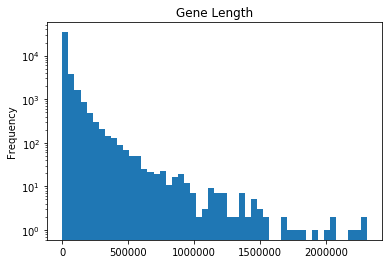

In [42]:
import matplotlib.pyplot as plt

ndf.length.plot(kind='hist', bins=50, logy=True)
plt.title("Gene Length")
plt.show()

# Majority of genes are within the first bin. However, some gene lengths can be more than two million bases.

In [43]:
ndf[ndf.length > 2e6].sort_values('length').ix[::-1]

# longest gene is named CNTNAP2, which is short for contactin associated protein-like 2

C:\Users\ankur\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  """Entry point for launching an IPython kernel.


,seqid,source,type,start,end,score,strand,phase,gene_name,gene_id,desc,length
2309345,7,ensembl_havana,gene,146116002,148420998,.,+,.,CNTNAP2,ENSG00000174469,contactin associated protein-like 2 [Source:HG...,2304997
2422510,9,ensembl_havana,gene,8314246,10612723,.,-,.,PTPRD,ENSG00000153707,protein tyrosine phosphatase%2C receptor type ...,2298478
2527169,X,ensembl_havana,gene,31097677,33339441,.,-,.,DMD,ENSG00000198947,dystrophin [Source:HGNC Symbol%3BAcc:HGNC:2928],2241765
440886,11,ensembl_havana,gene,83455012,85627922,.,-,.,DLG2,ENSG00000150672,discs large MAGUK scaffold protein 2 [Source:H...,2172911
2323457,8,ensembl_havana,gene,2935353,4994972,.,-,.,CSMD1,ENSG00000183117,CUB and Sushi multiple domains 1 [Source:HGNC ...,2059620
1569914,20,ensembl_havana,gene,13995369,16053197,.,+,.,MACROD2,ENSG00000172264,MACRO domain containing 2 [Source:HGNC Symbol%...,2057829


In [44]:
ndf.sort_values('length').head()

# can be as short as eight bases
# The lengths of the two extreme cases are five orders of magnitude apart (2.3 million vs. 8), 
# which is enormous and which can be an indication of the level of diversity of life.

# A single gene can be translated to many different proteins via a process called alternative splicing.

,seqid,source,type,start,end,score,strand,phase,gene_name,gene_id,desc,length
682278,14,havana,gene,22438547,22438554,.,+,.,TRDD1,ENSG00000223997,T cell receptor delta diversity 1 [Source:HGNC...,8
682282,14,havana,gene,22439007,22439015,.,+,.,TRDD2,ENSG00000237235,T cell receptor delta diversity 2 [Source:HGNC...,9
2306836,7,havana,gene,142786213,142786224,.,+,.,TRBD1,ENSG00000282431,T cell receptor beta diversity 1 [Source:HGNC ...,12
682286,14,havana,gene,22449113,22449125,.,+,.,TRDD3,ENSG00000228985,T cell receptor delta diversity 3 [Source:HGNC...,13
1879625,4,havana,gene,10238213,10238235,.,-,.,AC006499.9,ENSG00000271544,,23


In [46]:
ndf = ndf[ndf.seqid.isin(chrs)]
chr_gene_counts = ndf.groupby('seqid').count().ix[:, 0].sort_values().ix[::-1]
chr_gene_counts

# Borrowed the chrs variable from the previous section, and used it to filter out the unassembled sequences. Based on the output, the largest Chromosome 1 indeed has the most genes. 
# While Chromosome Y has the smallest number of genes, it is not the smallest chromosome.

C:\Users\ankur\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  


seqid
1     3902
2     2806
11    2561
19    2412
17    2280
3     2204
6     2154
12    2140
7     2106
5     2002
16    1881
X     1852
4     1751
9     1659
8     1628
10    1600
15    1476
14    1449
22     996
20     965
13     872
18     766
21     541
Y      436
Name: source, dtype: int64

In [47]:
df[(df.type == 'gene') & (df.seqid == 'MT')]

,seqid,source,type,start,end,score,strand,phase,attributes
2514003,MT,insdc,gene,648,1601,.,+,.,ID=gene:ENSG00000211459;Name=MT-RNR1;biotype=M...
2514009,MT,insdc,gene,1671,3229,.,+,.,ID=gene:ENSG00000210082;Name=MT-RNR2;biotype=M...
2514016,MT,insdc,gene,3307,4262,.,+,.,ID=gene:ENSG00000198888;Name=MT-ND1;biotype=pr...
2514029,MT,insdc,gene,4470,5511,.,+,.,ID=gene:ENSG00000198763;Name=MT-ND2;biotype=pr...
2514048,MT,insdc,gene,5904,7445,.,+,.,ID=gene:ENSG00000198804;Name=MT-CO1;biotype=pr...
2514058,MT,insdc,gene,7586,8269,.,+,.,ID=gene:ENSG00000198712;Name=MT-CO2;biotype=pr...
2514065,MT,insdc,gene,8366,8572,.,+,.,ID=gene:ENSG00000228253;Name=MT-ATP8;biotype=p...
2514069,MT,insdc,gene,8527,9207,.,+,.,ID=gene:ENSG00000198899;Name=MT-ATP6;biotype=p...
2514073,MT,insdc,gene,9207,9990,.,+,.,ID=gene:ENSG00000198938;Name=MT-CO3;biotype=pr...
2514080,MT,insdc,gene,10059,10404,.,+,.,ID=gene:ENSG00000198840;Name=MT-ND3;biotype=pr...


In [48]:
gdf = gdf[gdf.seqid.isin(chrs)]
gdf.drop(['start', 'end', 'score', 'strand', 'phase' ,'attributes'], axis=1, inplace=True)
gdf.sort_values('length').ix[::-1]

C:\Users\ankur\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  This is separate from the ipykernel package so we can avoid doing imports until


,seqid,source,type,length
0,1,GRCh38,chromosome,248956422
1364641,2,GRCh38,chromosome,242193529
1705855,3,GRCh38,chromosome,198295559
1864567,4,GRCh38,chromosome,190214555
1964921,5,GRCh38,chromosome,181538259
2080148,6,GRCh38,chromosome,170805979
2196981,7,GRCh38,chromosome,159345973
2514125,X,GRCh38,chromosome,156040895
2321361,8,GRCh38,chromosome,145138636
2416560,9,GRCh38,chromosome,138394717


In [49]:
cdf = chr_gene_counts.to_frame(name='gene_count').reset_index()
cdf.head(2)

,seqid,gene_count
0,1,3902
1,2,2806


In [50]:
merged = gdf.merge(cdf, on='seqid')
merged

,seqid,source,type,length,gene_count
0,1,GRCh38,chromosome,248956422,3902
1,10,GRCh38,chromosome,133797422,1600
2,11,GRCh38,chromosome,135086622,2561
3,12,GRCh38,chromosome,133275309,2140
4,13,GRCh38,chromosome,114364328,872
5,14,GRCh38,chromosome,107043718,1449
6,15,GRCh38,chromosome,101991189,1476
7,16,GRCh38,chromosome,90338345,1881
8,17,GRCh38,chromosome,83257441,2280
9,18,GRCh38,chromosome,80373285,766


In [52]:
merged[['length', 'gene_count']].corr()

# .corr calculates the Pearson correlation between all pairs of columns in a dataframe

,length,gene_count
length,1.000000,0.728221
gene_count,0.728221,1.000000


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


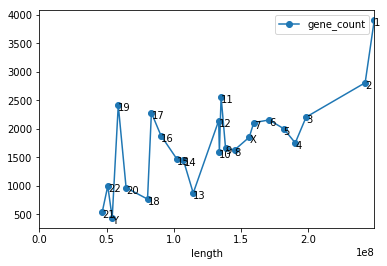

In [53]:
# plot the two columns after sorting the value pairs by length

ax = merged[['length', 'gene_count']].sort_values('length').plot(x='length', y='gene_count', style='o-')
# add some margin to both ends of x axis
xlim = ax.get_xlim()
margin = xlim[0] * 0.1
ax.set_xlim([xlim[0] - margin, xlim[1] + margin])
# Label each point on the graph
for (s, x, y) in merged[['seqid', 'length', 'gene_count']].sort_values('length').values:
    ax.text(x, y - 100, str(s))
    
# Positive correlation in overall 
# Chromosome 17, 16, 15, 14, 13, the correlation is actually negative, 
# meaning the number of genes on the chromosome decreases as the chromosome size increases.

#### In summary:

- About 0.37% of the human genome is still incomplete even though the first draft came out over 15 years ago.
- There are about 42,000 genes in the human genome based on this particular GFF3 file we used.
- The length of a gene can range from a few dozen to over two million bases.
- Genes are not evenly distributed among the chromosomes. Overall, the larger the chromosome, the more genes it hosts, but for a subset of the chromosomes, the correlation can be negative.